## Fred Garcia (fbg2107)
Homework Assignment 2: Profiling Small LLM Workloads

- let's start by getting the system info


In [1]:
import torch
import psutil
import transformers
from transformers import (
    DistilBertForSequenceClassification,
    DistilBertTokenizer,
    DataCollatorWithPadding,
)
from datasets import load_dataset
from torch.utils.data import DataLoader
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import wandb
import numpy as np
import random
import platform
import time

# gpu information
print(f"GPU : {torch.cuda.get_device_name(0)}")
gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU mem: {gpu_memory:.1f} GB")
# cpu information
print(f"CPU Model: {platform.processor()}")
print(
    f"CPU Cores: {psutil.cpu_count(logical=False)} physical, {psutil.cpu_count(logical=True)} logical"
)
# pytorch and transformers versions
print(f"PyTorch Version: {torch.__version__}")
print(f"Transformers Version: {transformers.__version__}")
# CUDA version (
print(f"CUDA version: {torch.version.cuda}")
# misc
print(f"Python Version: {platform.python_version()}")
print(f"system node RAM: {psutil.virtual_memory().total / (1024**3):.1f} GB")

/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/mnt/home/fgarcia/py_venves/hpml/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' a

GPU : NVIDIA A100-SXM4-80GB
GPU mem: 85.2 GB
CPU Model: x86_64
CPU Cores: 64 physical, 64 logical
PyTorch Version: 2.9.0+cu128
Transformers Version: 4.57.1
CUDA version: 12.8
Python Version: 3.10.4
system node RAM: 1007.6 GB


In [2]:
# # get the wandb going
# wandb.init(project="hpml-hw2-llm")

# wandb.config.update(
#     {
#         "model_name": "distilbert-base-uncased",
#         "max_len": 256,
#         "batch_size": 32,
#         "lr": 1e-4,
#         "optimizer": "AdamW",
#         "num_workers": 2,
#         "epochs": 5,
#         "compile_mode": False,
#     }
# )

We can group runs by C, so it seems like C1 and C2 are asking for basically the same run but differnt profiling metrics?
We can just do separate runs with the same config but different profiling/logging code

In [3]:
# set seeds
seed = 144
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

load data and inspect

In [4]:
dataset = load_dataset("imdb")

In [5]:
print(f"train samples: {len(dataset['train'])}")
print(f"test samples: {len(dataset['test'])}")

# we can print the text in some training set
test_index = 144
print(f"sample review: {dataset['train'][144]['text'][:]}...")
print(f"label: {dataset['train'][144]['label']}")

train samples: 25000
test samples: 25000
sample review: I won't say this movie was bad, but it wasn't good either. I expected something good but I guess Hum Aapke Hain Kaun was much better than this. This was completely old fashioned. At every stage of this movie, I hoped for some twist and what do I get? The girl gets burned and wins her aunt's love. <br /><br />Despite of being engaged, they have to take permission for every little move they make. They are so darn shy even after so many meetings. I expected the aunt to be much more brutal than that. All she did was crib madly. <br /><br />Hey, we have kids too, but we don't watch them and have tears in our eyes always. This movie is a dream. Happy family, one cruel woman, good in-laws and a man who loves her to death. In HAHK Anupam Kher was the poor bride's father and now it's vice versa. And I somehow knew that Mohnish Behl would be in this movie. Anyway I believe I wasted my time. I give it a 2/10....
label: 0


ok it looks like we are looking at text and seeing if the movie is good or not (0 for bad, 1 for good)


the rest of the section for __Dataset and Model__




In [6]:
model_name = "distilbert-base-uncased"

# tokenaize
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=2)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# move model to device with CUDA synchronization capability
device = torch.device("cuda")
model = model.to(device)

In [8]:
# we were told to use fixed sequence length so text will get truncated with this
MAX_LENGTH = 256
EPOCHS = 5

## C1

tokenzation (fixed length)

In [9]:
# we tocanize in this cell
# - sets truncation to true to cut off long reviews


def tokenize_function(examples):
    """tokenize with fixed max length , no padding (dynamic padding in collate_fn)"""
    return tokenizer(
        examples["text"],
        truncation=True,
        padding=False,  # dynamic padding handled in collate_fn
        max_length=MAX_LENGTH,  # fixed length for comparisons
        return_tensors=None,
    )


# we defined a function just for clarity, and apply his
tokenized_datasets = dataset.map(tokenize_function, batched=True)

# remove text column and set format-- the words now will be turned into input_ids and attention_mask
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets.set_format("torch")

In [10]:
# use Hugging Face's built-in collator for dynamic padding
# pad to longest sequence in batch
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding="longest",  # pad to longest sequence in batch
    return_tensors="pt",  # return PyTorch tensors
)

train_dataloader = DataLoader(
    tokenized_datasets["train"],
    batch_size=32,
    shuffle=True,
    collate_fn=data_collator,
    num_workers=2,  # can use >0 since DataCollator is picklable
)

test_dataloader = DataLoader(
    tokenized_datasets["test"],
    batch_size=32,
    shuffle=False,
    collate_fn=data_collator,
    num_workers=2,
)


print(f"train batches: {len(train_dataloader)}, test batches: {len(test_dataloader)}")
sample_batch = next(iter(train_dataloader))
print(
    f"sample batch - input_ids: {sample_batch['input_ids'].shape}, attention_mask: {sample_batch['attention_mask'].shape}"
)

train batches: 782, test batches: 782
sample batch - input_ids: torch.Size([32, 256]), attention_mask: torch.Size([32, 256])


In [11]:
#######
C1_wandb_config = {
    "model_name": "distilbert-base-uncased",
    "max_len": 256,
    "batch_size": 32,
    "lr": 1e-4,
    "optimizer": "AdamW",
    "num_workers": 2,
    "epochs": EPOCHS,
    "component": "C1_baseline",
}

# create meaningful run name and group
run_name = f"bs_{C1_wandb_config['batch_size']}_lr_{C1_wandb_config['lr']}_C1"
group_name = "C1_fine_tuning"

wandb.init(
    project="hpml-hw2-llm", name=run_name, group=group_name, config=C1_wandb_config
)
########

optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

train_losses = []
train_accuracies = []
test_accuracies = []


def compute_accuracy(logits, labels):
    """compute accuracy given logits and true labels"""
    predictions = torch.argmax(logits, dim=-1)
    return (predictions == labels).float().mean()


for epoch in range(EPOCHS):
    print(f"epoch {epoch + 1}/{EPOCHS}")

    # training
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    train_batches = 0

    for batch in tqdm(train_dataloader, desc="training"):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        acc = compute_accuracy(logits, batch["labels"])
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        train_batches += 1

    avg_train_loss = total_train_loss / train_batches
    avg_train_acc = total_train_acc / train_batches

    # evaluation
    model.eval()
    total_test_acc = 0
    test_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc="Testing"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            acc = compute_accuracy(outputs.logits, batch["labels"])
            total_test_acc += acc.item()
            test_batches += 1

    avg_test_acc = total_test_acc / test_batches

    # store metrics needed
    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    test_accuracies.append(avg_test_acc)

    # log to W&B
    wandb.log(
        {
            "train/loss": avg_train_loss,
            "train/accuracy": avg_train_acc,
            "test/accuracy": avg_test_acc,
            "epoch": epoch + 1,
        }
    )

    print(
        f"train Loss: {avg_train_loss:.4f}, train Acc: {avg_train_acc:.4f}, test Acc: {avg_test_acc:.4f}"
    )

wandb: Currently logged in as: fgarcia4 (fgarcia4-columbia-uni) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


epoch 1/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 17.96it/s]


train Loss: 0.3084, train Acc: 0.8691, test Acc: 0.9009
epoch 2/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.03it/s]


...

train Loss: 0.0866, train Acc: 0.9695, test Acc: 0.8816
epoch 4/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.12it/s]


train Loss: 0.0546, train Acc: 0.9809, test Acc: 0.8794
epoch 5/5


Testing: 100%|██████████| 782/782 [00:43<00:00, 18.05it/s]

train Loss: 0.0383, train Acc: 0.9877, test Acc: 0.8698


### Figure F1

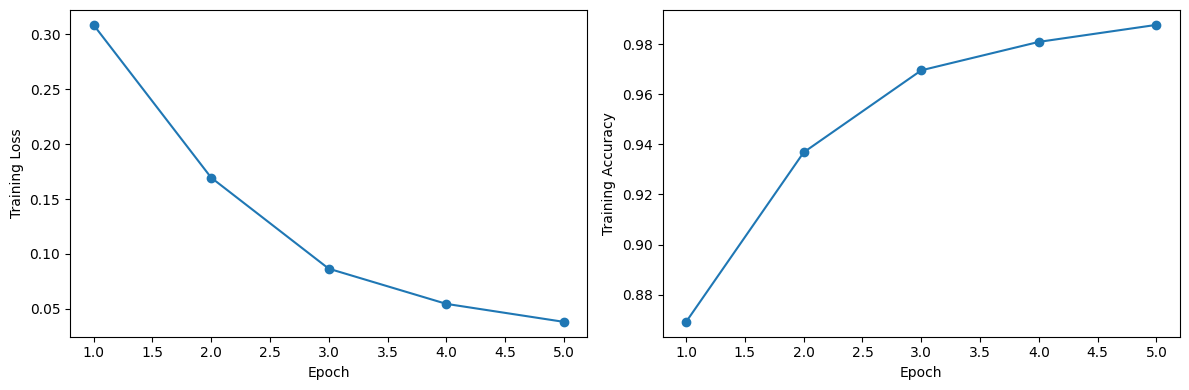

In [12]:
# This creates Figure F1
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: Training loss decreasing over epochs
ax[0].plot(range(1, EPOCHS + 1), train_losses, marker="o")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("Training Loss")


# Right plot: Training and test accuracy increasing over epochs
ax[1].plot(range(1, EPOCHS + 1), train_accuracies, marker="o")
# ax[1].plot(range(1, 6), test_accuracies, marker="s", label="test accuracy")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Training Accuracy")
# ax[1].legend()


plt.tight_layout()
plt.savefig("./C1_F1.png", dpi=300, bbox_inches="tight")
plt.show()

### Table T1

In [13]:
table_t1 = pd.DataFrame(
    {
        "Epoch": range(1, EPOCHS + 1),
        "Train Loss": [f"{loss:.4f}" for loss in train_losses],
        "Train Accuracy": [f"{acc:.4f}" for acc in train_accuracies],
        "Test Accuracy": [f"{acc:.4f}" for acc in test_accuracies],
    }
)
table_t1
wandb.log({"C2_Table_T1": wandb.Table(dataframe=table_t1)})
wandb.finish()

epoch,▁▃▅▆█
test/accuracy,█▆▄▃▁
train/accuracy,▁▅▇██
train/loss,█▄▂▁▁
epoch,5
test/accuracy,0.86977
train/accuracy,0.98765
train/loss,0.03827


## C2: baseline timing


we don't need the test eval loop according to post #107

In [14]:
######
C2_wandb_config = {
    "model_name": "distilbert-base-uncased",
    "sequence_length": 256,
    "batch_size": 32,
    "learning_rate": 1e-4,
    "optimizer": "AdamW",
    "number_dataloader_workers": 2,
    "epochs": 5,
    "device": "cuda",
    "torch_compile_enabled": False,
}
group_name = "C2_baseline_timing"
run_name = f"bs_{C2_wandb_config['batch_size']}_lr_{C2_wandb_config['learning_rate']}_C2"  # same config as C1 for fair timing comparison
wandb.init(
    project="hpml-hw2-llm", name=run_name, group=group_name, config=C2_wandb_config
)
######


# measuring: (a) data-loading time, (b) training compute time, (c) total epoch time
epoch_times = []  # (c) total training epoch time
data_loading_times = []  # (a) data loading time per epoch
compute_times = []  # (b) compute time per epoch (forward + backward + optimizer)

for epoch in range(5):
    print(f"Epoch {epoch + 1}/5")

    # training phase - with all timing components
    model.train()
    total_train_loss = 0
    total_train_acc = 0
    train_batches = 0

    # timing variables for this epoch's TRAINING
    epoch_data_loading_time = 0  # (a) Data loading time
    epoch_compute_time = 0  # (b) Compute time

    # start epoch timer (c) Total epoch time
    epoch_start_time = time.time()

    for batch in tqdm(train_dataloader, desc=f"Timing Epoch {epoch+1}"):
        # data loading time
        data_load_start = time.time()

        batch = {k: v.to(device) for k, v in batch.items()}

        # CUDA synchronization for accurate timing
        torch.cuda.synchronize()

        data_load_end = time.time()
        epoch_data_loading_time += data_load_end - data_load_start

        # (b) COMPUTE TIME (forward + backward + optimizer)
        compute_start = time.time()

        # forward pass
        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        # backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        torch.cuda.synchronize()  # CUDA sync for accurate timing

        compute_end = time.time()
        epoch_compute_time += compute_end - compute_start

        # metrics (not timed - part of compute overhead)
        acc = compute_accuracy(logits, batch["labels"])
        total_train_loss += loss.item()
        total_train_acc += acc.item()
        train_batches += 1

    # end epoch timer for training only
    epoch_end_time = time.time()
    epoch_total_time = epoch_end_time - epoch_start_time

    # timing consistency check (data + compute ~ total)
    timing_sum = epoch_data_loading_time + epoch_compute_time
    timing_diff = epoch_total_time - timing_sum
    print(
        f"   Timing check: Data+Compute={timing_sum:.2f}s, Total={epoch_total_time:.2f}s, Diff={timing_diff:.2f}s"
    )

    # store timing metrics
    epoch_times.append(epoch_total_time)
    data_loading_times.append(epoch_data_loading_time)
    compute_times.append(epoch_compute_time)

    # calculate training metrics
    avg_train_loss = total_train_loss / train_batches
    avg_train_acc = total_train_acc / train_batches

    # evaluation phase - NO TIMING FOR C2
    model.eval()
    total_test_acc = 0
    test_batches = 0

    with torch.no_grad():
        for batch in tqdm(test_dataloader, desc=f"Testing Epoch {epoch+1}"):
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            acc = compute_accuracy(outputs.logits, batch["labels"])
            total_test_acc += acc.item()
            test_batches += 1

    avg_test_acc = total_test_acc / test_batches

    # log to W&B - TRAINING TIMING ONLY
    wandb.log(
        {
            "train/loss": avg_train_loss,
            "train/accuracy": avg_train_acc,
            "test/accuracy": avg_test_acc,
            "time/data_loading": epoch_data_loading_time,  # (a)
            "time/compute": epoch_compute_time,  # (b)
            "time/epoch_total": epoch_total_time,  # (c)
            "epoch": epoch + 1,
        }
    )

    print(f"Epoch {epoch+1} Complete")
    print(f"   (a) Data Loading: {epoch_data_loading_time:.2f}s")
    print(f"   (b) Compute Time: {epoch_compute_time:.2f}s")
    print(f"   (c) Total Epoch:  {epoch_total_time:.2f}s")
    print(f"   Test Accuracy:    {avg_test_acc:.4f}")

Epoch 1/5


Timing Epoch 1: 100%|██████████| 782/782 [02:07<00:00,  6.11it/s]


   Timing check: Data+Compute=124.87s, Total=127.97s, Diff=3.10s


Testing Epoch 1: 100%|██████████| 782/782 [00:43<00:00, 18.06it/s]


Epoch 1 Complete
   (a) Data Loading: 0.15s
   (b) Compute Time: 124.72s
   (c) Total Epoch:  127.97s
   Test Accuracy:    0.8671
Epoch 2/5


...

Epoch 4 Complete
   (a) Data Loading: 0.15s
   (b) Compute Time: 124.62s
   (c) Total Epoch:  127.88s
   Test Accuracy:    0.8324
Epoch 5/5


Timing Epoch 5: 100%|██████████| 782/782 [02:07<00:00,  6.11it/s]


   Timing check: Data+Compute=124.83s, Total=128.01s, Diff=3.18s


Testing Epoch 5: 100%|██████████| 782/782 [00:43<00:00, 18.06it/s]

Epoch 5 Complete
   (a) Data Loading: 0.15s
   (b) Compute Time: 124.68s
   (c) Total Epoch:  128.01s
   Test Accuracy:    0.8490


### Table T2 

In [52]:
# Create Table T2: Per-epoch timing metrics
table_t2 = pd.DataFrame(
    {
        "Epoch": range(1, 6),
        "Data Loading Time (s)": [f"{t:.4f}" for t in data_loading_times],
        "Compute Time (s)": [f"{t:.4f}" for t in compute_times],
        "Total Epoch Time (s)": [f"{t:.4f}" for t in epoch_times],
        "Device (GPU)": [torch.cuda.get_device_name(0)] * 5,
    }
)
table_t2

# Save table
# table_t2.to_csv('C2_timing_metrics.csv', index=False)

,Epoch,Data Loading Time (s),Compute Time (s),Total Epoch Time (s),Device (GPU)
0,1,0.1407,124.6936,128.4380,NVIDIA A100-SXM4-80GB
1,2,0.1353,124.6723,128.1004,NVIDIA A100-SXM4-80GB
2,3,0.1416,124.6331,128.0129,NVIDIA A100-SXM4-80GB
3,4,0.1462,124.6081,128.0571,NVIDIA A100-SXM4-80GB
4,5,0.1149,124.6602,127.7348,NVIDIA A100-SXM4-80GB


In [16]:
wandb.log({"C2_Table_T2": wandb.Table(dataframe=table_t2)})
wandb.finish()

epoch,▁▃▅▆█
test/accuracy,█▅▅▁▄
time/compute,█▁█▂▅
time/data_loading,▇█▁▅█
time/epoch_total,▅█▆▁▇
train/accuracy,▁▃▂▄█
train/loss,█▅▆▅▁
epoch,5
test/accuracy,0.84898
time/compute,124.67739
time/data_loading,0.14829


### Figure F2

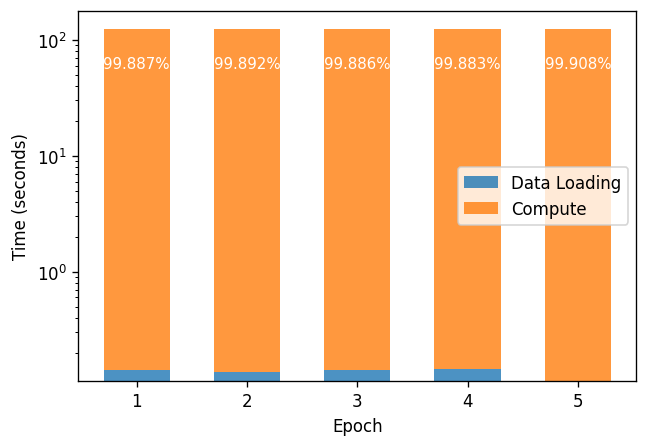

In [45]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=120)

# Create stacked bars for training timing only
epochs = range(1, 6)
bar_width = 0.6

bars1 = ax.bar(
    epochs,
    data_loading_times,
    bar_width,
    label="Data Loading",
    alpha=0.8,
)
bars2 = ax.bar(
    epochs,
    compute_times,
    bar_width,
    bottom=data_loading_times,
    label="Compute",
    alpha=0.8,
)

# Add labels and formatting
ax.set(xlabel="Epoch", ylabel="Time (seconds)", yscale="log")

ax.set_xticks(epochs)
ax.legend()


# add compute percentage labels on bars
for i, (data_time, compute_time) in enumerate(zip(data_loading_times, compute_times)):
    total_time = data_time + compute_time
    compute_pct = (compute_time / total_time) * 100
    ax.text(
        i + 1,
        data_time + compute_time / 2,
        f"{compute_pct:.3f}%",
        ha="center",
        va="center",
        fontsize=9,
        color="white",
    )


plt.savefig("C2_F2.png", dpi=300, bbox_inches="tight")
plt.show()

## C3: DataLoader Performance Comparison

In [18]:
# Test different num_workers values
num_workers_list = [0, 2, 4, 8]
results = []

for num_workers in num_workers_list:
    print(f"testing num_workers = {num_workers}")
    # W&B Configuration for this run
    wandb_config = {
        "model_name": "distilbert-base-uncased",
        "sequence_length": 256,
        "batch_size": 32,
        "learning_rate": 1e-4,
        "optimizer": "AdamW",
        "number_dataloader_workers": num_workers,  # Varied parameter
        "epochs": 5,
        "device": "cuda",
        "torch_compile_enabled": False,
        "component": "C3_dataloader",
    }

    run_name = f"bs_32_lr_1e-4_workers_{num_workers}"
    group_name = "C3_num_workers_compare"

    wandb.init(
        project="hpml-hw2-llm", name=run_name, group=group_name, config=wandb_config
    )

    # recreate DataLoaders with current num_workers
    train_dataloader = DataLoader(
        tokenized_datasets["train"],
        batch_size=32,
        shuffle=True,
        collate_fn=data_collator,
        num_workers=num_workers,  # This is what we're testing
    )

    # reinitialize model and optimizer for fair comparison
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased", num_labels=2
    )
    model = model.to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

    # training metrics storage for this run - ADD TRAIN LOSSES
    epoch_times = []
    data_loading_times = []
    compute_times = []
    train_accuracies = []
    train_losses = []  # NEW: Store training losses
    test_accuracies = []

    # training loop with timing (similar to C2)
    for epoch in range(5):
        print(f"Epoch {epoch + 1}/5 - workers={num_workers}")

        # Training phase with timing
        model.train()
        epoch_data_loading_time = 0
        epoch_compute_time = 0
        total_train_acc = 0
        total_train_loss = 0  # NEW: Track training loss
        train_batches = 0

        epoch_start_time = time.time()

        for batch in tqdm(train_dataloader, desc=f"workers={num_workers}"):
            # data loading time
            data_load_start = time.time()
            batch = {k: v.to(device) for k, v in batch.items()}
            torch.cuda.synchronize()
            data_load_end = time.time()
            epoch_data_loading_time += data_load_end - data_load_start

            # compute time
            compute_start = time.time()
            outputs = model(**batch)
            loss = outputs.loss
            logits = outputs.logits

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            torch.cuda.synchronize()
            compute_end = time.time()
            epoch_compute_time += compute_end - compute_start

            # metrics
            acc = compute_accuracy(logits, batch["labels"])
            total_train_acc += acc.item()
            total_train_loss += loss.item()  # NEW: Accumulate loss
            train_batches += 1

        epoch_end_time = time.time()
        epoch_total_time = epoch_end_time - epoch_start_time

        # Calculate average training loss for this epoch
        avg_train_loss = total_train_loss / train_batches
        avg_train_acc = total_train_acc / train_batches

        # store metrics
        epoch_times.append(epoch_total_time)
        data_loading_times.append(epoch_data_loading_time)
        compute_times.append(epoch_compute_time)
        train_accuracies.append(avg_train_acc)
        train_losses.append(avg_train_loss)  # NEW: Store average loss

        # quick test evaluation (no timing)
        model.eval()
        total_test_acc = 0
        test_batches = 0
        with torch.no_grad():
            for batch in test_dataloader:
                batch = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**batch)
                acc = compute_accuracy(outputs.logits, batch["labels"])
                total_test_acc += acc.item()
                test_batches += 1

        test_accuracies.append(total_test_acc / test_batches)

        # Log to W&B - ADD TRAINING LOSS
        wandb.log(
            {
                "train/loss": avg_train_loss,  # NEW: Add training loss
                "train/accuracy": train_accuracies[-1],
                "test/accuracy": test_accuracies[-1],
                "time/data_loading": epoch_data_loading_time,
                "time/compute": epoch_compute_time,
                "time/epoch_total": epoch_total_time,
                "epoch": epoch + 1,
            }
        )

        print(
            f"   Time: Data={epoch_data_loading_time:.2f}s, Compute={epoch_compute_time:.2f}s, Total={epoch_total_time:.2f}s"
        )
        print(
            f"   Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracies[-1]:.4f}, Test Acc: {test_accuracies[-1]:.4f}"  # Updated to show loss
        )

    # store results for this num_workers - ADD FINAL TRAIN LOSS
    avg_epoch_time = np.mean(epoch_times)
    avg_data_loading_time = np.mean(data_loading_times)
    avg_compute_time = np.mean(compute_times)
    final_train_loss = train_losses[-1]  # NEW: Final training loss
    final_train_acc = train_accuracies[-1]
    final_test_acc = test_accuracies[-1]

    results.append(
        {
            "num_workers": num_workers,
            "avg_epoch_time": avg_epoch_time,
            "avg_data_loading_time": avg_data_loading_time,
            "avg_compute_time": avg_compute_time,
            "final_train_loss": final_train_loss,  # NEW
            "final_train_accuracy": final_train_acc,
            "final_test_accuracy": final_test_acc,
        }
    )

    print(f"num_workers={num_workers} Summary:")
    print(f"avg Epoch Time: {avg_epoch_time:.2f}s")
    print(f"final Train Loss: {final_train_loss:.4f}")  # NEW
    print(
        f"avg Data Loading: {avg_data_loading_time:.2f}s ({avg_data_loading_time/avg_epoch_time*100:.1f}%)"
    )
    print(f"final Test Accuracy: {final_test_acc:.4f}")

    wandb.finish()

testing num_workers = 0


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch 1/5 - workers=0


workers=0: 100%|██████████| 782/782 [02:12<00:00,  5.92it/s]


   Time: Data=0.14s, Compute=123.62s, Total=132.01s
   Loss: 0.3084, Train Acc: 0.8686, Test Acc: 0.9005
Epoch 2/5 - workers=0


...

workers=8: 100%|██████████| 782/782 [02:08<00:00,  6.11it/s]


   Time: Data=0.15s, Compute=124.61s, Total=128.06s
   Loss: 0.0567, Train Acc: 0.9809, Test Acc: 0.8523
Epoch 5/5 - workers=8


workers=8: 100%|██████████| 782/782 [02:07<00:00,  6.12it/s]


   Time: Data=0.11s, Compute=124.66s, Total=127.73s
   Loss: 0.0395, Train Acc: 0.9867, Test Acc: 0.8651
num_workers=8 Summary:
avg Epoch Time: 128.07s
final Train Loss: 0.0395
avg Data Loading: 0.14s (0.1%)
final Test Accuracy: 0.8651


epoch,▁▃▅▆█
test/accuracy,██▁▂▄
time/compute,█▆▃▁▅
time/data_loading,▇▆▇█▁
time/epoch_total,█▅▄▄▁
train/accuracy,▁▅▇██
train/loss,█▄▂▁▁
epoch,5
test/accuracy,0.86513
time/compute,124.66017
time/data_loading,0.11492


In [ ]:
table_t3_data = []
for result in results:
    row = {
        "Num Workers": result["num_workers"],
        "Avg Epoch Time (s)": f"{result['avg_epoch_time']:.2f}",
        "Avg Data Loading Time (s)": f"{result['avg_data_loading_time']:.2f}",
        "Avg Compute Time (s)": f"{result['avg_compute_time']:.2f}",
        "Final Train Loss": f"{result['final_train_loss']:.4f}",
        "Final Train Accuracy": f"{result['final_train_accuracy']:.4f}",
        "Final Test Accuracy": f"{result['final_test_accuracy']:.4f}",
        "Batch Size": 32,
    }
    table_t3_data.append(row)
    print(
        f"{result['num_workers']:<12} {result['avg_epoch_time']:<18.2f} {result['avg_data_loading_time']:<25.2f} {result['avg_compute_time']:<20.2f} {result['final_train_loss']:<16.4f} {result['final_train_accuracy']:<16.4f} {result['final_test_accuracy']:<15.4f}"
    )

table_t3 = pd.DataFrame(table_t3_data)

0            131.62             0.11                      123.66               0.0427           0.9860           0.8683         
2            127.63             0.12                      124.65               0.0397           0.9864           0.8685         
4            127.95             0.13                      124.71               0.0391           0.9877           0.8752         
8            128.07             0.14                      124.65               0.0395           0.9867           0.8651         


### Table T3

In [47]:
# display only num_workers and avg epoch time and avg data loading time and batch size
table_t3[
    ["Num Workers", "Avg Epoch Time (s)", "Avg Data Loading Time (s)", "Batch Size"]
]

,Num Workers,Avg Epoch Time (s),Avg Data Loading Time (s),Batch Size
0,0,131.62,0.11,32
1,2,127.63,0.12,32
2,4,127.95,0.13,32
3,8,128.07,0.14,32


### Figure F3
line plot of avg epoch time vs num workers

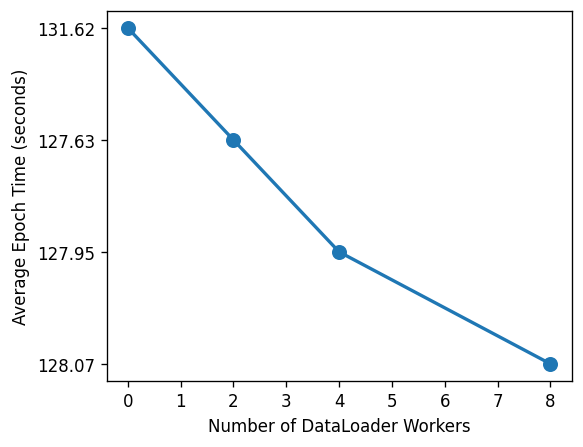

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4), dpi=120)
ax.plot(
    np.array(table_t3["Num Workers"]),
    np.array(table_t3["Avg Epoch Time (s)"]),
    marker="o",
    linewidth=2,
    markersize=8,
)

# reverse y axis
ax.invert_yaxis()
ax.set(xlabel="Number of DataLoader Workers", ylabel="Average Epoch Time (seconds)")
plt.savefig("C3_num_workers_performance.png", dpi=300, bbox_inches="tight")
plt.show()

#### One sentence conclusion about the results

There is a linear decrease in average epoch time as the number of DataLoader workers increases from 0 - 4, but going to 8 diminishes returns due to overhead from managing too many workers. The best is thus 4 workers for this setup.


## C4: PyTorch Profiler 



In [ ]:
import torch.profiler as profiler
from torch.profiler import profile, record_function, ProfilerActivity

PROFILER_BATCHES = 782  # Representative slice
SKIP_BATCHES = 1  # Skip first batch
WARMUP_BATCHES = 9  # Warmup batches
NUM_TOP_OPS = 10  # Number of top operations to display

In [ ]:
def run_profiler(num_workers, device="cuda"):
    """
    Profile one full epoch of DistilBERT training for C4.
    Logs per-phase percentages (for Table T4) and produces Figure F4 bar charts.
    """

    # ---- W&B setup ----
    wandb_config = {
        "model_name": "distilbert-base-uncased",
        "max_len": 256,
        "batch_size": 32,
        "lr": 1e-4,
        "optimizer": "AdamW",
        "num_workers": num_workers,
        "epochs": 1,
        "device": device,
        "component": "C4_profiler",
    }

    wandb.init(
        project="hpml-hw2-llm",
        name=f"C4_profiler_nw_{num_workers}",
        group="C4_profiler_nw_compare",
        config=wandb_config,
        reinit=True,
    )

    # ---- dataLoader & model ----
    train_loader = DataLoader(
        tokenized_datasets["train"],
        batch_size=32,
        shuffle=True,
        num_workers=num_workers,
        collate_fn=data_collator,
    )

    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased"
    ).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
    criterion = torch.nn.CrossEntropyLoss()
    model.train()

    # ---- profiler ----
    trace_dir = f"./profiler_nw{num_workers}"
    with profile(
        activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
        record_shapes=False,
        profile_memory=False,
        on_trace_ready=torch.profiler.tensorboard_trace_handler(trace_dir),
    ) as prof:

        epoch_start = time.time()

        for batch in tqdm(
            train_loader, desc=f"Profiling epoch (num_workers={num_workers})"
        ):
            inputs = {k: v.to(device) for k, v in batch.items()}
            labels = inputs.pop("labels")

            with record_function("forward"):
                outputs = model(**inputs)
                loss = criterion(outputs.logits, labels)

            with record_function("backward"):
                optimizer.zero_grad()
                loss.backward()

            with record_function("optimizer_step"):
                optimizer.step()

            prof.step()

        torch.cuda.synchronize()
        epoch_time = time.time() - epoch_start

    # ---- summary breakdown ----
    key_avg = prof.key_averages()
    total_cpu_time = sum(evt.self_cpu_time_total for evt in key_avg)
    get_pct = (
        lambda substr: sum(
            evt.self_cpu_time_total for evt in key_avg if substr in evt.key
        )
        / total_cpu_time
        * 100
    )

    breakdown = {
        "Setting": f"nw={num_workers}",
        "Data (%)": get_pct("DataLoader"),
        "Forward (%)": get_pct("forward"),
        "Backward (%)": get_pct("backward"),
        "Optimizer (%)": get_pct("optimizer"),
        "Epoch Time (s)": epoch_time,
    }

    wandb.log(
        {
            "epoch_time_s": epoch_time,
            "data_percent": breakdown["Data (%)"],
            "forward_percent": breakdown["Forward (%)"],
            "backward_percent": breakdown["Backward (%)"],
            "optimizer_percent": breakdown["Optimizer (%)"],
        }
    )

    # # ---- breakdown bar chart ----
    # fig, ax = plt.subplots(figsize=(5, 4))
    # bars = ["Data", "Forward", "Backward", "Optimizer"]
    # vals = [breakdown[f"{b} (%)"] for b in bars]
    # ax.bar(bars, vals, color=["skyblue", "orange", "lightgreen", "salmon"])
    # ax.set_ylabel("Percent of Total CPU Time")
    # ax.set_title(f"Breakdown (num_workers={num_workers})")
    # plt.tight_layout()
    # wandb.log({"breakdown_bar": wandb.Image(fig)})
    # plt.close(fig)

    wandb.finish()

    print(f"\nTrace saved to: {trace_dir}")
    print(pd.DataFrame([breakdown]))
    return breakdown, prof

In [87]:
res1, prof1 = run_profiler(1)
res4, prof4 = run_profiler(4)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Profiling epoch (num_workers=1): 100%|██████████| 782/782 [02:07<00:00,  6.16it/s]


backward_percent,▁
data_percent,▁
epoch_time_s,▁
forward_percent,▁
optimizer_percent,▁
backward_percent,6.57838
data_percent,1.74071
epoch_time_s,127.02025
forward_percent,1.25839
optimizer_percent,0.02522



Trace saved to: ./profiler_nw1
  Setting  Data (%)  Forward (%)  Backward (%)  Optimizer (%)  Epoch Time (s)
0    nw=1  1.740713     1.258395      6.578379       0.025221      127.020251


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Profiling epoch (num_workers=4): 100%|██████████| 782/782 [02:09<00:00,  6.06it/s]


backward_percent,▁
data_percent,▁
epoch_time_s,▁
forward_percent,▁
optimizer_percent,▁
backward_percent,6.60568
data_percent,2.15384
epoch_time_s,129.02185
forward_percent,1.2805
optimizer_percent,0.02662



Trace saved to: ./profiler_nw4
  Setting  Data (%)  Forward (%)  Backward (%)  Optimizer (%)  Epoch Time (s)
0    nw=4  2.153838     1.280505       6.60568       0.026619      129.021852


### Table T4: 

In [88]:
t4 = pd.DataFrame([res1, res4])
display(t4)

,Setting,Data (%),Forward (%),Backward (%),Optimizer (%),Epoch Time (s)
0,nw=1,1.740713,1.258395,6.578379,0.025221,127.020251
1,nw=4,2.153838,1.280505,6.605680,0.026619,129.021852


### Figure  F4

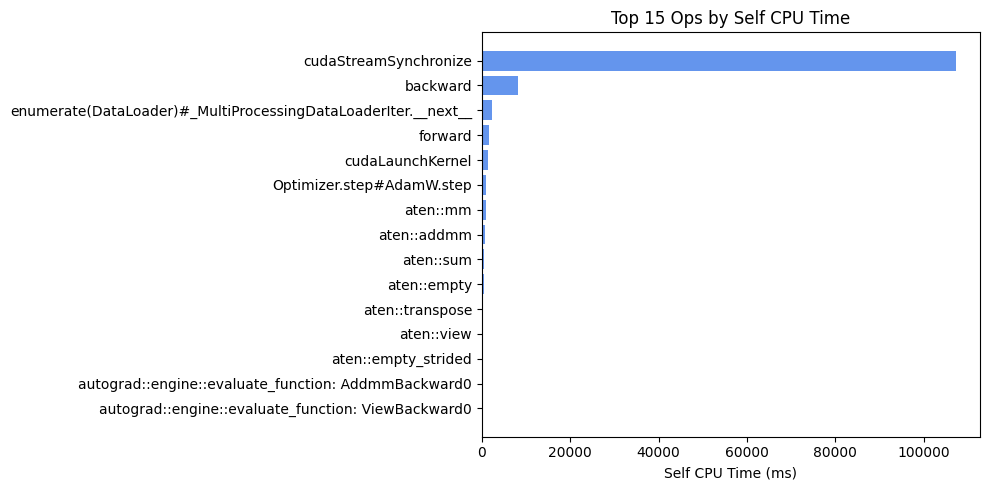

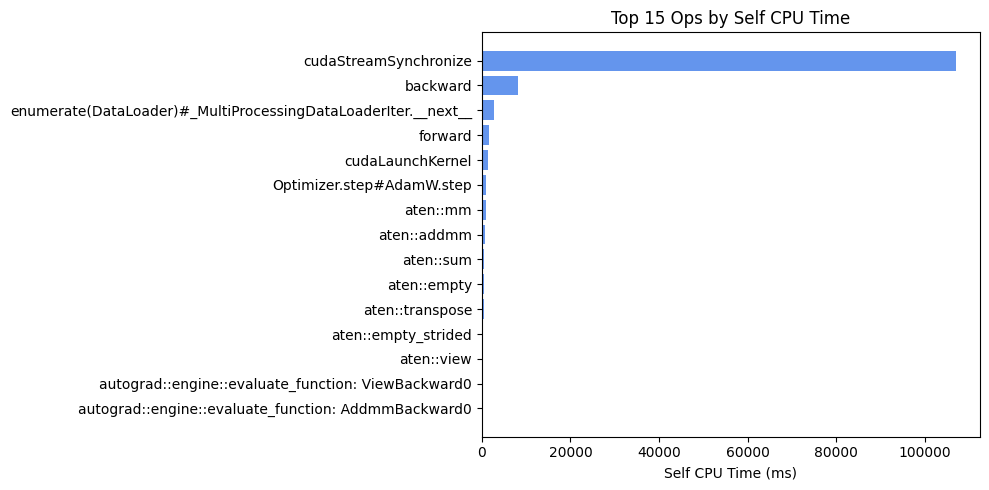

,op,cpu_time_ms
18,cudaStreamSynchronize,107140.581050
84,backward,8272.129919
9,enumerate(DataLoader)#_MultiProcessingDataLoad...,2850.353893
19,forward,1613.066710
27,cudaLaunchKernel,1456.007407
146,Optimizer.step#AdamW.step,1012.785623
97,aten::mm,855.404258
63,aten::addmm,724.385104
98,aten::sum,457.126839
0,aten::empty,456.190004


In [91]:
def plot_top_ops(prof, top_k=15):
    events = prof.key_averages()
    data = []
    for evt in events:
        data.append(
            {
                "op": evt.key,
                "cpu_time_ms": evt.self_cpu_time_total / 1e3,
                # "cuda_time_ms": evt.self_cuda_time_total / 1e3,
            }
        )
    df = pd.DataFrame(data)

    # sort separately
    top_cpu = df.sort_values("cpu_time_ms", ascending=False).head(top_k)
    # top_gpu = df.sort_values("cuda_time_ms", ascending=False).head(top_k)

    # ---- CPU ----
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(top_cpu["op"], top_cpu["cpu_time_ms"], color="cornflowerblue")
    ax.set_xlabel("Self CPU Time (ms)")
    ax.set_title(f"Top {top_k} Ops by Self CPU Time")
    ax.invert_yaxis()

    plt.show()

    # # ---- GPU ----
    # plt.figure(figsize=(10, 5))
    # plt.barh(top_gpu["op"], top_gpu["cuda_time_ms"], color="darkorange")
    # plt.xlabel("Self GPU Time (ms)")
    # plt.title(f"Top {top_k} Ops by Self GPU Time")
    # plt.gca().invert_yaxis()
    # plt.tight_layout()
    # plt.show()

    return top_cpu


plot_top_ops(prof1, top_k=15)
plot_top_ops(prof4, top_k=15)

In [92]:
print(prof1.key_averages().table(sort_by="cpu_time_total", row_limit=10))
print(prof4.key_averages().table(sort_by="cpu_time_total", row_limit=10))

-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                            aten::copy_         0.06%      72.900ms        81.63%      107.568s      10.581ms      63.510ms         0.05%      63.516ms       6.248us         10166  
                                               aten::to         0.01%      19.217ms        81.62%      107.556s       6.832ms       0.000us         0.00%      31.212ms       1.982us         15744  
         

## C5 
Train for 5 epochs on CPU and on GPU. Keep batch size and max length fixed across both.


,Config,Data Loading %,Forward %,Backward %,Optimizer %,Other %,Total Time (s)
0,nw=1,1.1%,0.1%,2.3%,1.5%,95.1%,32.5
1,nw=best,1.2%,0.1%,2.2%,1.5%,95.0%,32.5
